# Evaluate the RaCA SOC model

RaCA performance uses predictions made while each site was held out. DSP4SH is a fully external evaluation set. Primary reporting includes row-level and 250 m pixel × 10 cm depth-bin metrics, followed by shallow/deep diagnostics.

In [1]:
from pathlib import Path
import sys

PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / 'code').exists():
    PROJECT_DIR = PROJECT_DIR.parent
sys.path.insert(0, str(PROJECT_DIR / 'code'))
from modeling_pipeline import evaluate_saved_run

evaluation = evaluate_saved_run(PROJECT_DIR)
evaluation['metrics']

,dataset,n,R2,RMSE,MAE,Bias,Mean_observed,Mean_predicted
0,RaCA grouped OOF — rows,25705,0.498229,1.208624,0.652927,-0.156067,1.386602,1.230535
1,RaCA grouped OOF — 250m pixel × 10cm depth,24324,0.503848,1.177007,0.629447,-0.150817,1.343341,1.192523
2,DSP4SH external — rows,1586,0.599868,0.902404,0.522555,-0.264875,1.478661,1.213786
3,DSP4SH external — 250m pixel × 10cm depth,684,0.627940,0.682662,0.431122,-0.270560,1.217376,0.946816


In [2]:
evaluation['depth_metrics']

,dataset,n,R2,RMSE,MAE,Bias,Mean_observed,Mean_predicted,depth_group,evaluation
0,0–30 cm,13186,0.410991,1.502649,0.913346,-0.226763,2.106447,1.879684,0–30 cm,RaCA grouped OOF
1,>30 cm,12519,0.241798,0.788111,0.378633,-0.081604,0.628404,0.546800,>30 cm,RaCA grouped OOF
2,0–30 cm,825,0.486365,1.146337,0.705839,-0.318824,2.185063,1.866239,0–30 cm,DSP4SH external
3,>30 cm,761,0.199498,0.522062,0.323856,-0.206389,0.712851,0.506462,>30 cm,DSP4SH external


Matplotlib is building the font cache; this may take a moment.


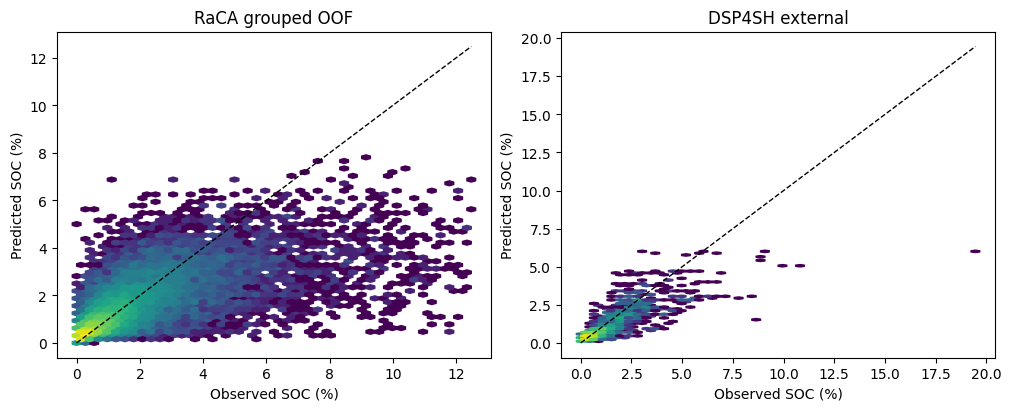

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for ax, frame, title in [
    (axes[0], evaluation['raca_oof'], 'RaCA grouped OOF'),
    (axes[1], evaluation['dsp'], 'DSP4SH external'),
]:
    ax.hexbin(frame.observed_SOC_pct, frame.predicted_SOC_pct, gridsize=45, mincnt=1, bins='log')
    upper = max(frame.observed_SOC_pct.max(), frame.predicted_SOC_pct.max())
    ax.plot([0, upper], [0, upper], '--', color='black', linewidth=1)
    ax.set(title=title, xlabel='Observed SOC (%)', ylabel='Predicted SOC (%)')
plt.show()